
# **BISMILLAH FINAL PROJECT**

### **Step 1 : Collecting Dataset**

Dataset Collected
1. Energy Consumption Sector Industry, Household, and Commercial. Source : HANDBOOK OF ENERGY & ECONOMIC STATISTICS OF INDONESIA (2016,2019,& 2024)
2. Emisson CO2. Source : www.ourworldindata.org
3. Emission Greenhouse. Source : www.ourworldindata.org
4. Change Surface Temperature. Source : International Monetary Fund (IMF) climate data

### **Step 2 : Preprocessing Dataset**

### 1. Panggil Library yang akan digunakan

In [1]:
import pandas as pd
import numpy as np
from IPython.display import Markdown, display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import io
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from scipy.stats import boxcox, yeojohnson
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, Nadam, RMSprop
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import pyinform
import itertools
import time

### 2. Data Energi Sektor Industri

In [2]:
industri= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiIndustri.csv",delimiter=';')
industri

,Year,Biomass,Coal,Geothermal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,58981,36060,n.a,85,66826,4219,37171,8008,n.a,25581,74979,13435,1073,20850,292289
1,2001,55186,37021,n.a,78,81861,4160,39458,7735,n.a,26680,78033,25712,972,21819,300683
2,2002,52303,38698,n.a,83,80508,3955,38282,7311,n.a,25596,75690,22688,1093,22578,299643
3,2003,50167,68264,n.a,77,89912,3980,37398,6358,n.a,20756,68493,23533,808,22337,323626
4,2004,46917,55344,n.a,80,85076,4012,42986,5862,n.a,25194,74178,37716,1101,24719,325670
5,2005,43920,65744,n.a,94,86277,3851,39929,4843,n.a,15617,64239,29614,1131,26021,317040
6,2006,46676,89043,n.a,94,82845,3394,35027,2627,n.a,16154,57203,41126,1453,26736,345178
7,2007,42108,121904,n.a,89,79723,3352,33787,1422,n.a,13856,52418,39873,1242,28077,365434
8,2008,44235,94035,n.a,155,90227,2676,30095,865,n.a,27482,61118,n.a,1127,29405,320302
9,2009,44521,82587,n.a,220,89101,1619,32238,706,n.a,24888,59451,n.a,588,28323,304791


In [3]:
industri.insert(loc=1, column='Sector', value='Industri')
industri

,Year,Sector,Biomass,Coal,Geothermal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,Industri,58981,36060,n.a,85,66826,4219,37171,8008,n.a,25581,74979,13435,1073,20850,292289
1,2001,Industri,55186,37021,n.a,78,81861,4160,39458,7735,n.a,26680,78033,25712,972,21819,300683
2,2002,Industri,52303,38698,n.a,83,80508,3955,38282,7311,n.a,25596,75690,22688,1093,22578,299643
3,2003,Industri,50167,68264,n.a,77,89912,3980,37398,6358,n.a,20756,68493,23533,808,22337,323626
4,2004,Industri,46917,55344,n.a,80,85076,4012,42986,5862,n.a,25194,74178,37716,1101,24719,325670
5,2005,Industri,43920,65744,n.a,94,86277,3851,39929,4843,n.a,15617,64239,29614,1131,26021,317040
6,2006,Industri,46676,89043,n.a,94,82845,3394,35027,2627,n.a,16154,57203,41126,1453,26736,345178
7,2007,Industri,42108,121904,n.a,89,79723,3352,33787,1422,n.a,13856,52418,39873,1242,28077,365434
8,2008,Industri,44235,94035,n.a,155,90227,2676,30095,865,n.a,27482,61118,n.a,1127,29405,320302
9,2009,Industri,44521,82587,n.a,220,89101,1619,32238,706,n.a,24888,59451,n.a,588,28323,304791


In [4]:
# Missing Values
industri = industri.replace('n.a', np.nan).fillna(0)
industri

,Year,Sector,Biomass,Coal,Geothermal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,Industri,58981,36060,0,85,66826,4219,37171,8008,0,25581,74979,13435,1073,20850,292289
1,2001,Industri,55186,37021,0,78,81861,4160,39458,7735,0,26680,78033,25712,972,21819,300683
2,2002,Industri,52303,38698,0,83,80508,3955,38282,7311,0,25596,75690,22688,1093,22578,299643
3,2003,Industri,50167,68264,0,77,89912,3980,37398,6358,0,20756,68493,23533,808,22337,323626
4,2004,Industri,46917,55344,0,80,85076,4012,42986,5862,0,25194,74178,37716,1101,24719,325670
5,2005,Industri,43920,65744,0,94,86277,3851,39929,4843,0,15617,64239,29614,1131,26021,317040
6,2006,Industri,46676,89043,0,94,82845,3394,35027,2627,0,16154,57203,41126,1453,26736,345178
7,2007,Industri,42108,121904,0,89,79723,3352,33787,1422,0,13856,52418,39873,1242,28077,365434
8,2008,Industri,44235,94035,0,155,90227,2676,30095,865,0,27482,61118,0,1127,29405,320302
9,2009,Industri,44521,82587,0,220,89101,1619,32238,706,0,24888,59451,0,588,28323,304791


### 3. Data Energi Sektor Rumah Tangga

In [5]:
rumahtangga= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiRumahTangga.csv",delimiter=';')
rumahtangga

,Year,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,208610,81,63216,5932,18735,296573
1,2001,212323,87,62329,6170,20437,301347
2,2002,216465,96,59261,6373,20838,303033
3,2003,220377,99,59640,7013,21917,309046
4,2004,223425,124,60112,6798,23655,314115
5,2005,224707,124,57696,5998,25246,313772
6,2006,228186,128,50862,6719,26821,312716
7,2007,231616,132,50229,8345,29010,319333
8,2008,68422,131,40096,13487,30763,152899
9,2009,63082,130,24255,22767,33682,143915


In [6]:
rumahtangga.insert(loc=1, column='Sector', value='Rumah Tangga')
rumahtangga

,Year,Sector,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,Rumah Tangga,208610,81,63216,5932,18735,296573
1,2001,Rumah Tangga,212323,87,62329,6170,20437,301347
2,2002,Rumah Tangga,216465,96,59261,6373,20838,303033
3,2003,Rumah Tangga,220377,99,59640,7013,21917,309046
4,2004,Rumah Tangga,223425,124,60112,6798,23655,314115
5,2005,Rumah Tangga,224707,124,57696,5998,25246,313772
6,2006,Rumah Tangga,228186,128,50862,6719,26821,312716
7,2007,Rumah Tangga,231616,132,50229,8345,29010,319333
8,2008,Rumah Tangga,68422,131,40096,13487,30763,152899
9,2009,Rumah Tangga,63082,130,24255,22767,33682,143915


In [7]:
#Mengelola Missing Values
rumahtangga = rumahtangga.replace('n.a', np.nan).fillna(0)
rumahtangga

,Year,Sector,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,Rumah Tangga,208610,81,63216,5932,18735,296573
1,2001,Rumah Tangga,212323,87,62329,6170,20437,301347
2,2002,Rumah Tangga,216465,96,59261,6373,20838,303033
3,2003,Rumah Tangga,220377,99,59640,7013,21917,309046
4,2004,Rumah Tangga,223425,124,60112,6798,23655,314115
5,2005,Rumah Tangga,224707,124,57696,5998,25246,313772
6,2006,Rumah Tangga,228186,128,50862,6719,26821,312716
7,2007,Rumah Tangga,231616,132,50229,8345,29010,319333
8,2008,Rumah Tangga,68422,131,40096,13487,30763,152899
9,2009,Rumah Tangga,63082,130,24255,22767,33682,143915


### 4. Data Energi Sektor Komersial

In [8]:
komersial= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiKomersial.csv",delimiter=';')
komersial

,Year,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Total Fuel,LPG,Electricity,Total
0,2000,1452,134,3491,5352,43,n.a,8886,1257,8943,20670
1,2001,1444,147,3442,5682,42,n.a,9165,1138,9555,21450
2,2002,1437,164,3272,5591,39,n.a,8903,1279,9570,21752
3,2003,1430,158,3293,5385,34,n.a,8712,946,11151,22397
4,2004,1423,174,3319,6190,31,n.a,9540,1288,12986,25412
5,2005,1416,190,3186,5749,26,n.a,8961,1324,14344,26235
6,2006,1409,206,2809,5044,14,n.a,7866,1241,15473,26195
7,2007,1402,274,2774,4865,8,n.a,7646,1337,17237,27896
8,2008,1395,357,2214,4333,5,n.a,6552,1044,18871,28219
9,2009,1388,330,1394,4642,4,n.a,5985,1029,20482,29559


In [9]:
komersial.insert(loc=1, column='Sector', value='Komersial')
komersial

,Year,Sector,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Total Fuel,LPG,Electricity,Total
0,2000,Komersial,1452,134,3491,5352,43,n.a,8886,1257,8943,20670
1,2001,Komersial,1444,147,3442,5682,42,n.a,9165,1138,9555,21450
2,2002,Komersial,1437,164,3272,5591,39,n.a,8903,1279,9570,21752
3,2003,Komersial,1430,158,3293,5385,34,n.a,8712,946,11151,22397
4,2004,Komersial,1423,174,3319,6190,31,n.a,9540,1288,12986,25412
5,2005,Komersial,1416,190,3186,5749,26,n.a,8961,1324,14344,26235
6,2006,Komersial,1409,206,2809,5044,14,n.a,7866,1241,15473,26195
7,2007,Komersial,1402,274,2774,4865,8,n.a,7646,1337,17237,27896
8,2008,Komersial,1395,357,2214,4333,5,n.a,6552,1044,18871,28219
9,2009,Komersial,1388,330,1394,4642,4,n.a,5985,1029,20482,29559


In [10]:
#Mengelola Missing Values
komersial = komersial.replace('n.a', np.nan).fillna(0)
komersial

,Year,Sector,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Total Fuel,LPG,Electricity,Total
0,2000,Komersial,1452,134,3491,5352,43,0,8886,1257,8943,20670
1,2001,Komersial,1444,147,3442,5682,42,0,9165,1138,9555,21450
2,2002,Komersial,1437,164,3272,5591,39,0,8903,1279,9570,21752
3,2003,Komersial,1430,158,3293,5385,34,0,8712,946,11151,22397
4,2004,Komersial,1423,174,3319,6190,31,0,9540,1288,12986,25412
5,2005,Komersial,1416,190,3186,5749,26,0,8961,1324,14344,26235
6,2006,Komersial,1409,206,2809,5044,14,0,7866,1241,15473,26195
7,2007,Komersial,1402,274,2774,4865,8,0,7646,1337,17237,27896
8,2008,Komersial,1395,357,2214,4333,5,0,6552,1044,18871,28219
9,2009,Komersial,1388,330,1394,4642,4,0,5985,1029,20482,29559


### 5. Data Emsisi CO2 Indonesia

In [11]:
karbon= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/Data CO2 Indonesia.csv",delimiter=',')
karbon

,Entity,Year,Annual CO₂ emissions
0,Indonesia,2000,281330370
1,Indonesia,2001,317027200
2,Indonesia,2002,308485920
3,Indonesia,2003,339357470
4,Indonesia,2004,343021500
5,Indonesia,2005,347617020
6,Indonesia,2006,346633440
7,Indonesia,2007,387858050
8,Indonesia,2008,365718300
9,Indonesia,2009,398942050


In [12]:
karbon = karbon.rename(columns={"Annual CO₂ emissions": "Emission_CO₂"})
karbon

,Entity,Year,Emission_CO₂
0,Indonesia,2000,281330370
1,Indonesia,2001,317027200
2,Indonesia,2002,308485920
3,Indonesia,2003,339357470
4,Indonesia,2004,343021500
5,Indonesia,2005,347617020
6,Indonesia,2006,346633440
7,Indonesia,2007,387858050
8,Indonesia,2008,365718300
9,Indonesia,2009,398942050


### 6. Data Emisi GRK Indonesia

In [13]:
grk = pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/greenhouse-gas-emissions Indonesia.csv",delimiter=',')
grk

,Entity,Year,Annual greenhouse gas emissions in CO₂ equivalents
0,Indonesia,2000,1386973000
1,Indonesia,2001,1373519600
2,Indonesia,2002,1588074400
3,Indonesia,2003,1289581000
4,Indonesia,2004,1384788200
5,Indonesia,2005,1316794500
6,Indonesia,2006,1893063000
7,Indonesia,2007,1285662800
8,Indonesia,2008,1322040700
9,Indonesia,2009,1705499000


In [14]:
grk = grk.rename(columns={"Annual greenhouse gas emissions in CO₂ equivalents": "Emission_GRK"})
grk

,Entity,Year,Emission_GRK
0,Indonesia,2000,1386973000
1,Indonesia,2001,1373519600
2,Indonesia,2002,1588074400
3,Indonesia,2003,1289581000
4,Indonesia,2004,1384788200
5,Indonesia,2005,1316794500
6,Indonesia,2006,1893063000
7,Indonesia,2007,1285662800
8,Indonesia,2008,1322040700
9,Indonesia,2009,1705499000


### 7. Data Perubahan Permukaan Suhu Indonesia

In [15]:
suhu= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/Perubahan Permukaan Suhu Tahunan Indonesia.csv",delimiter=';')
suhu = suhu.replace('–', '-', regex=True)
suhu

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,97,Indonesia,ID,IDN,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.771,1.41,0.957,0.879,1.045,1.233,1.02,0.969,1.101,1.472


In [16]:
# Cek semua kolom yang berbentuk tahun
year_cols = [col for col in suhu.columns if col.isdigit()]
suhu[year_cols] = suhu[year_cols].apply(pd.to_numeric, errors='coerce')

# Lakukan melt
suhu_melted = pd.melt(
    suhu,
    id_vars=['Country', 'Unit'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Temperature'
)
suhu_melted

,Country,Unit,Year,Temperature
0,Indonesia,Degree Celsius,1961,-0.049
1,Indonesia,Degree Celsius,1962,0.016
2,Indonesia,Degree Celsius,1963,-0.105
3,Indonesia,Degree Celsius,1964,0.002
4,Indonesia,Degree Celsius,1965,-0.203
...,...,...,...,...
59,Indonesia,Degree Celsius,2020,1.233
60,Indonesia,Degree Celsius,2021,1.020
61,Indonesia,Degree Celsius,2022,0.969
62,Indonesia,Degree Celsius,2023,1.101


In [17]:
suhu_melted['Year'] = suhu_melted['Year'].astype(int)
suhu_filtered = suhu_melted[suhu_melted['Year'] >= 2000]
temp = suhu_filtered[['Country', 'Year', 'Temperature', 'Unit']].reset_index(drop=True)
temp

,Country,Year,Temperature,Unit
0,Indonesia,2000,0.234,Degree Celsius
1,Indonesia,2001,0.470,Degree Celsius
2,Indonesia,2002,0.594,Degree Celsius
3,Indonesia,2003,0.621,Degree Celsius
4,Indonesia,2004,0.574,Degree Celsius
5,Indonesia,2005,0.709,Degree Celsius
6,Indonesia,2006,0.388,Degree Celsius
7,Indonesia,2007,0.430,Degree Celsius
8,Indonesia,2008,0.226,Degree Celsius
9,Indonesia,2009,0.532,Degree Celsius


### **Step 3 : Exploration Data Anlysis**

In [18]:
#1 Statistic Descriptive Energy Consumption
display(Markdown("**1. Statistik Deskriptif Konsumsi Energi**"))

**1. Statistik Deskriptif Konsumsi Energi**

In [19]:
#1.1 Statistic Descriptive Energy Consumption by Industrial Sector
display(Markdown("**1.1 Statistik Deskriptif Konsumsi Energi Sektor Industri**"))
industri.describe().astype(int)

**1.1 Statistik Deskriptif Konsumsi Energi Sektor Industri**

,Year,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,Fuel Oil,Total Fuel,LPG,Electricity,Total
count,25,25,25,25,25,25,25,25,25,25,25,25,25
mean,2012,29627,112472,85,93541,1600,27291,2061,16689,50983,943,40086,338318
std,7,23007,85778,56,12691,1686,16012,2754,6527,18129,216,16643,90012
min,2000,45,36060,0,66826,170,1099,233,7669,22578,588,20850,237807
25%,2006,637,58800,50,85729,203,18517,314,11586,32288,788,26736,292289
50%,2012,43317,87820,85,91342,468,32238,544,14751,54108,972,36888,317040
75%,2018,46676,123022,121,105492,3394,38282,2627,21820,64239,1093,54638,363535
max,2024,58981,342672,220,119192,4219,49515,8008,27482,78033,1453,72811,586240


In [20]:
#1.2 Statistic Descriptive Energy Consumption by Household Sector
display(Markdown("**1.2 Statistik Deskriptif Konsumsi Energi Sektor Rumah Tangga**"))
rumahtangga.describe().astype(int)

**1.2 Statistik Deskriptif Konsumsi Energi Sektor Rumah Tangga**

,Year,Biomass,Gas,Kerosene,LPG,Electricity,Total
count,25,25,25,25,25,25,25
mean,2012,96312,268,23984,37417,45455,203475
std,7,88582,289,25271,26214,20082,74150
min,2000,15043,81,2551,5932,18735,143915
25%,2006,26622,122,3038,7013,26821,149436
50%,2012,55139,132,7015,41123,44217,158357
75%,2018,212323,239,50862,61819,60927,301347
max,2024,231616,1128,63216,76690,83450,319333


In [21]:
#1.3 Statistic Descriptive Energy Consumption by Commercial Sector
display(Markdown("**1.3 Statistik Deskriptif Konsumsi Energi Sektor Komersial**"))
komersial.describe().astype(int)

**1.3 Statistik Deskriptif Konsumsi Energi Sektor Komersial**

,Year,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
count,25,25,25,25,25,25,25,25,25,25
mean,2012,1367,681,1338,4035,11,5812,1401,25879,35293
std,7,50,466,1388,2219,14,2578,317,11712,10088
min,2000,1287,134,141,191,1,2236,946,8943,20670
25%,2006,1326,206,168,2666,2,2836,1139,15473,26235
50%,2012,1360,701,587,4840,3,5985,1324,26567,37655
75%,2018,1409,1204,2809,5591,14,7866,1628,36516,43175
max,2024,1452,1447,3491,7130,43,9540,2015,49709,58360


In [22]:
#2. Statistic Descriptive Data Climate Change by Emission CO2
display(Markdown("**2.1 Statistik Deskriptif Emisi CO2**"))
karbon.describe().astype(int)

**2.1 Statistik Deskriptif Emisi CO2**

,Year,Emission_CO₂
count,24,24
mean,2011,477401475
std,7,135565306
min,2000,281330370
25%,2005,347371125
50%,2011,488472525
75%,2017,566233500
max,2023,737072640


In [23]:
#2. Statistic Descriptive Data Climate Change by GreenHouse Effect
display(Markdown("**2.2 Statistik Deskriptif Emisi Gas Rumah Kaca**"))
grk.describe().round(0).astype('int64')

**2.2 Statistik Deskriptif Emisi Gas Rumah Kaca**

,Year,Emission_GRK
count,24,24
mean,2012,1688352658
std,7,299295752
min,2000,1285662800
25%,2006,1386426800
50%,2012,1709937800
75%,2017,1824891925
max,2023,2499634000


In [24]:
#2. Statistic Descriptive Data Climate Change by Change Surface Temperature
display(Markdown("**2.3 Statistik Deskriptif Perubahan Permukaan Suhu Tahunan**"))
temp.describe().astype(str)

**2.3 Statistik Deskriptif Perubahan Permukaan Suhu Tahunan**

,Year,Temperature
count,25.0,25.0
mean,2012.0,0.745
std,7.359800721939872,0.3447719052745839
min,2000.0,0.226
25%,2006.0,0.47
50%,2012.0,0.742
75%,2018.0,0.969
max,2024.0,1.472


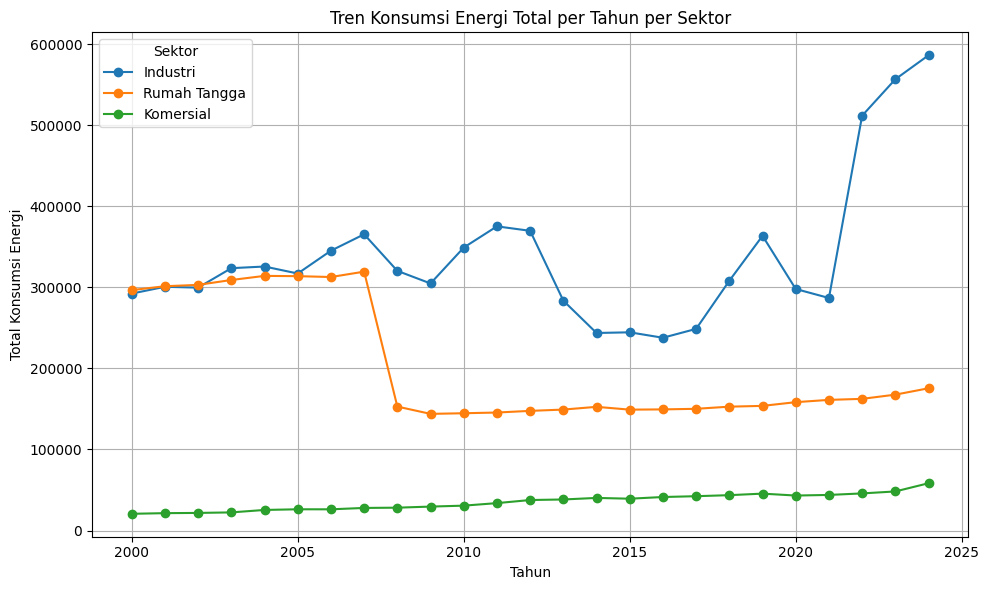

In [25]:
plt.figure(figsize=(10,6))

plt.plot(industri["Year"], industri["Total"], marker="o", label="Industri")
plt.plot(rumahtangga["Year"], rumahtangga["Total"], marker="o", label="Rumah Tangga")
plt.plot(komersial["Year"], komersial["Total"], marker="o", label="Komersial")

plt.title("Tren Konsumsi Energi Total per Tahun per Sektor")
plt.xlabel("Tahun")
plt.ylabel("Total Konsumsi Energi")
plt.legend(title="Sektor")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt
import math

def plot_dataset(df, title="Tren Konsumsi Energi", ncols=3):

    # ambil kolom numerik, kecuali Year & Total
    numeric_cols = df.select_dtypes(include="number").columns
    numeric_cols = [col for col in numeric_cols if col not in ["Year", "Total"]]

    n = len(numeric_cols)
    nrows = math.ceil(n / ncols)  # baris otomatis

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    fig.suptitle(title, fontsize=14, y=1.02)

    for i, col in enumerate(numeric_cols):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        ax.plot(df["Year"], df[col], marker="o", label=col)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Tahun")
        ax.set_ylabel("Konsumsi Energi")
        ax.grid(True)
        ax.legend(fontsize=8)

    # hapus subplot kosong kalau ada
    for j in range(i+1, nrows*ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    plt.tight_layout()
    plt.show()

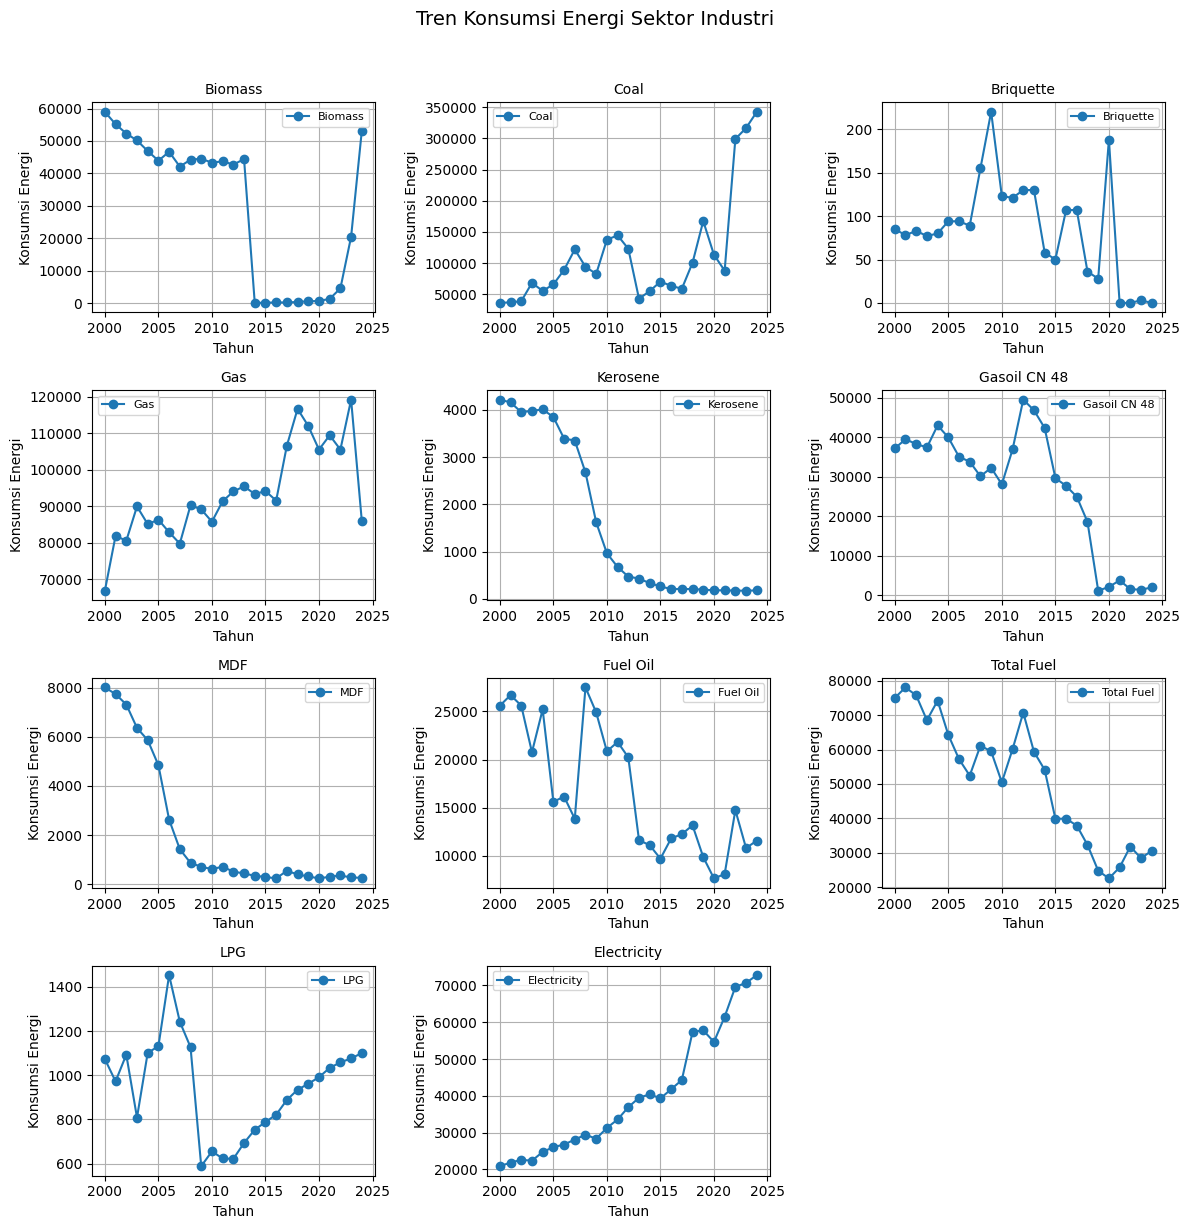

In [27]:
plot_dataset(industri, "Tren Konsumsi Energi Sektor Industri")

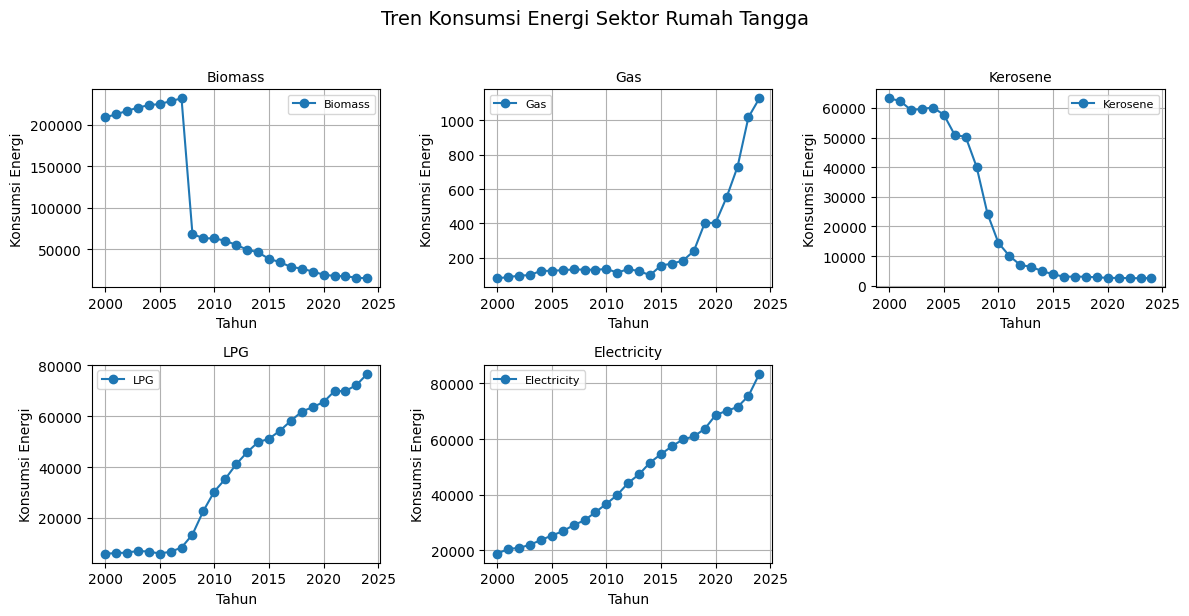

In [28]:
plot_dataset(rumahtangga, "Tren Konsumsi Energi Sektor Rumah Tangga")

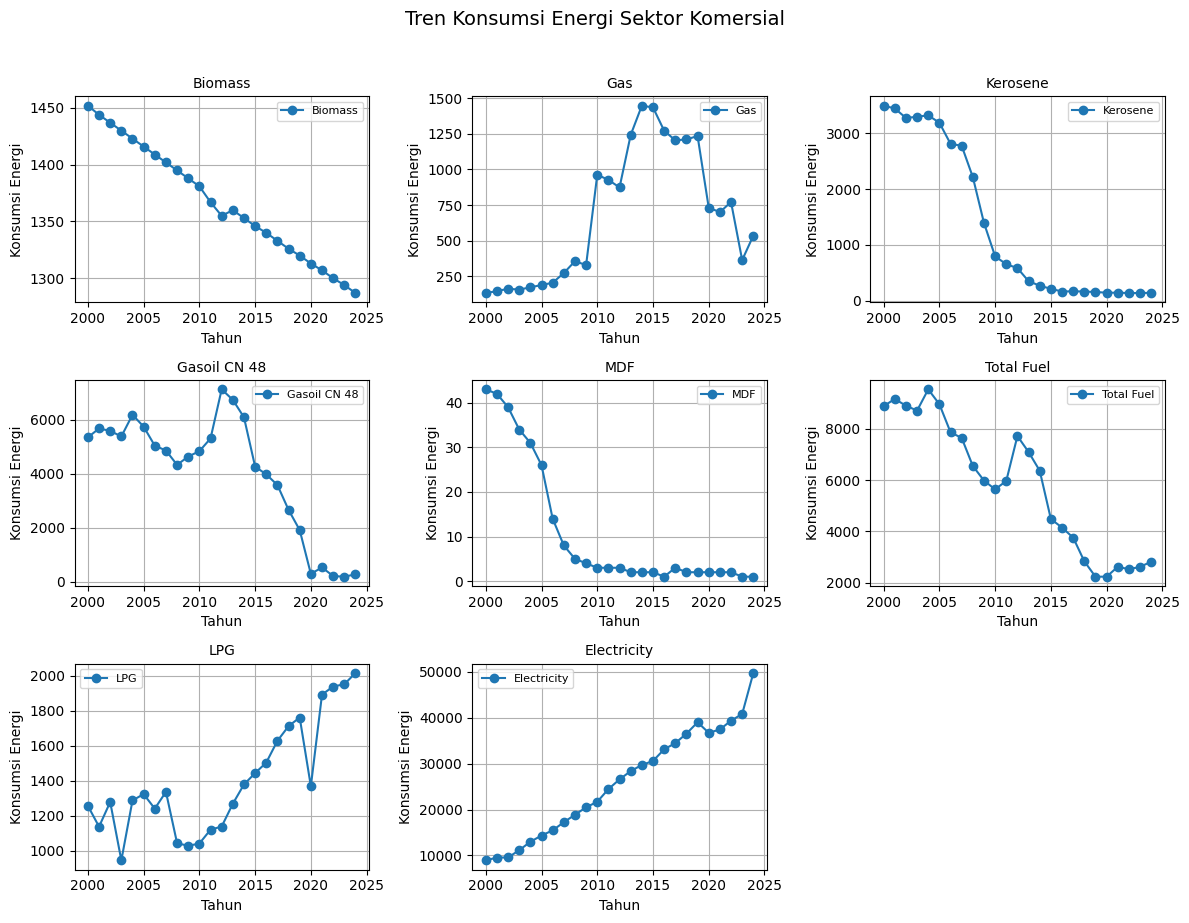

In [29]:
plot_dataset(komersial, "Tren Konsumsi Energi Sektor Komersial")

**3.2 Analisis Pola Emisi CO2**

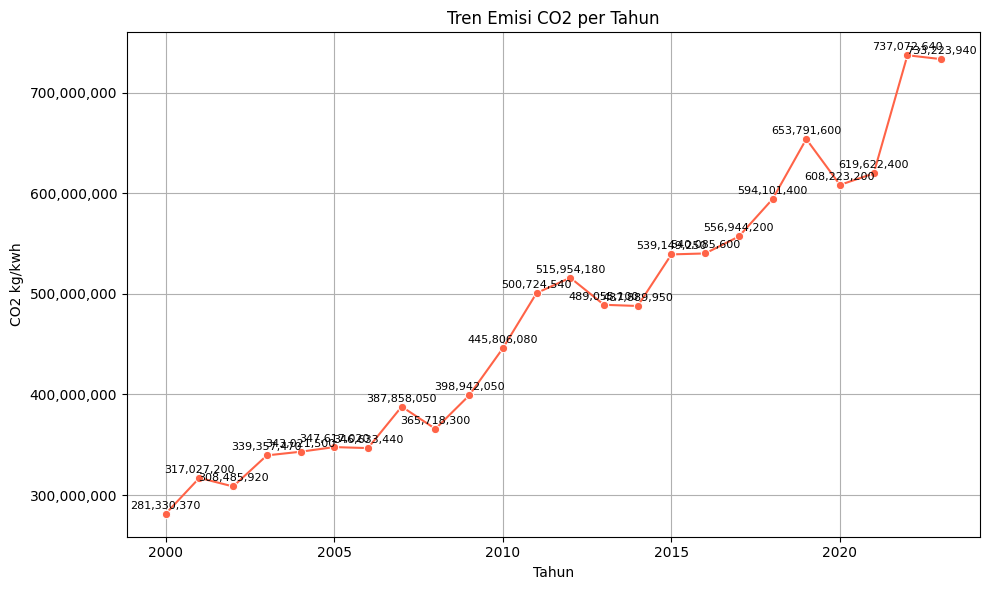

In [30]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.2 Analisis Pola Emisi CO2**"))

plt.figure(figsize=(10,6))
sns.lineplot(data=karbon, x='Year', y='Emission_CO₂', marker='o',color='tomato')

for x, y in zip(karbon['Year'], karbon['Emission_CO₂']):
    if pd.notna(y):
        plt.text(x, y + 5_000_000, f'{int(y):,}', ha='center', fontsize=8)

formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Tren Emisi CO2 per Tahun")
plt.xlabel("Tahun")
plt.ylabel("CO2 kg/kwh")
plt.grid(True)
plt.tight_layout()
plt.show()

**3.3 Analisis Pola Emisi Gas Rumah Kaca**

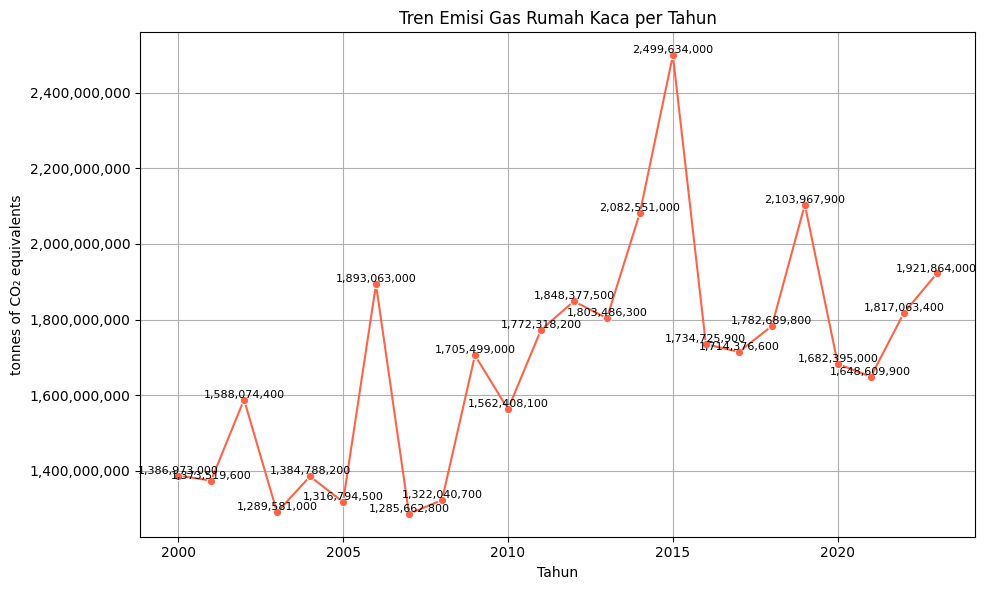

In [31]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.3 Analisis Pola Emisi Gas Rumah Kaca**"))

plt.figure(figsize=(10,6))
sns.lineplot(data=grk, x='Year', y='Emission_GRK', marker='o',color='tomato')

for x, y in zip(grk['Year'], grk['Emission_GRK']):
    if pd.notna(y):
        plt.text(x, y + 5_000_000, f'{int(y):,}', ha='center', fontsize=8)

formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Tren Emisi Gas Rumah Kaca per Tahun")
plt.xlabel("Tahun")
plt.ylabel("tonnes of CO₂ equivalents")
plt.grid(True)
plt.tight_layout()
plt.show()

**3.4 Analisis Pola Perubahan Suhu Permukaan**

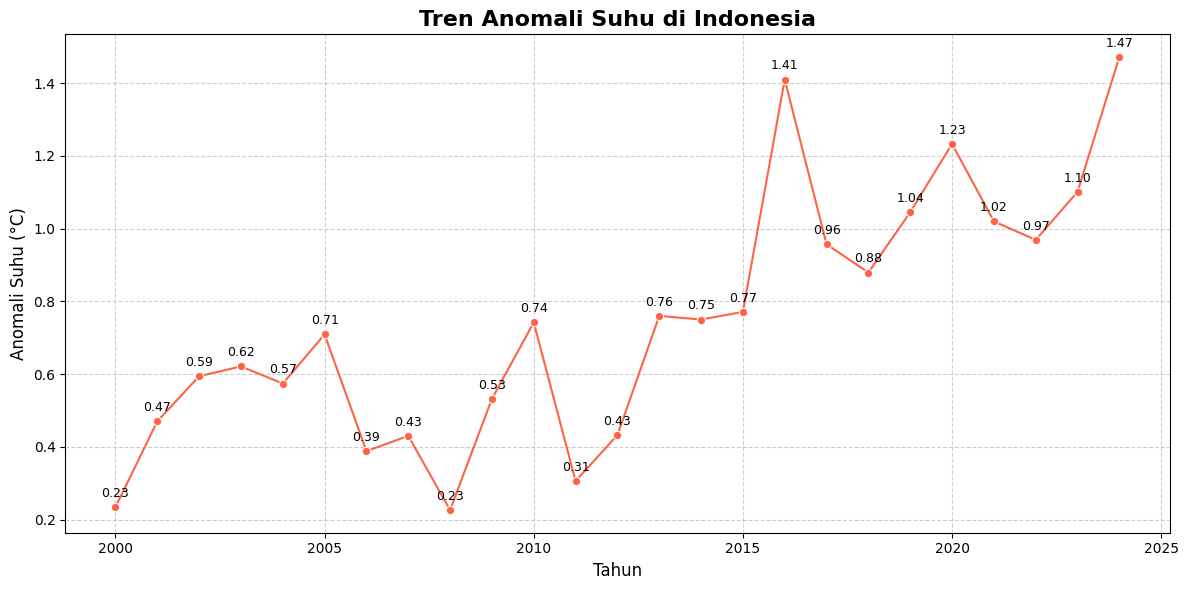

In [32]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.4 Analisis Pola Perubahan Suhu Permukaan**"))

temp['Year'] = temp['Year'].astype(int)
temp['Temperature'] = temp['Temperature'].astype(float)

plt.figure(figsize=(12,6))
sns.lineplot(data=temp, x='Year', y='Temperature', marker='o', color='tomato')

for x, y in zip(temp['Year'], temp['Temperature']):
    plt.text(x, y+0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=9, color='black')

plt.title('Tren Anomali Suhu di Indonesia', fontsize=16, weight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Anomali Suhu (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
#3. Correlation beetween each dataset
display(Markdown("**3. Korelasi antar dataset**"))

**3. Korelasi antar dataset**

**3.2 Korelasi Data Energi Industri dengan Perubahan Iklim**

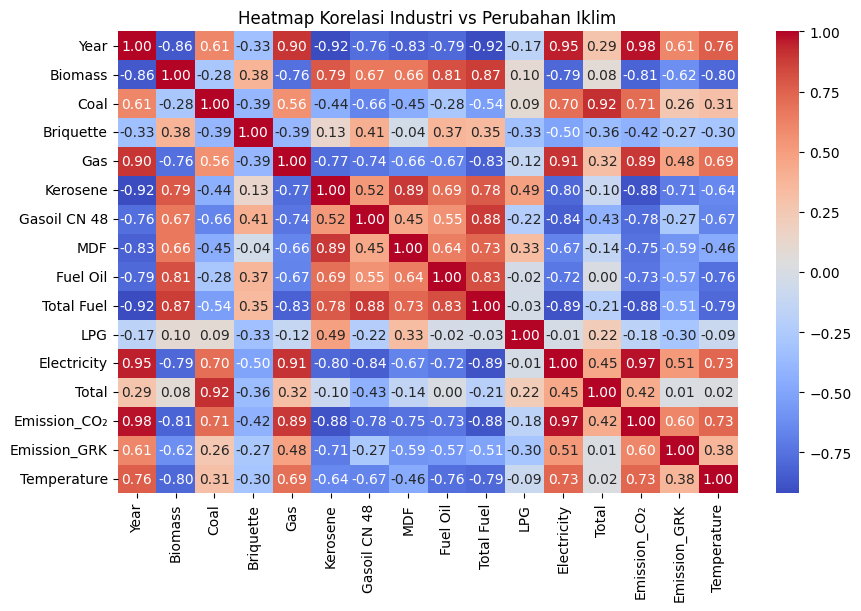

In [34]:
#3. Correlation beetween each dataset
display(Markdown("**3.2 Korelasi Data Energi Industri dengan Perubahan Iklim**"))

# Menggabungkan data industri dan karbon berdasarkan Year
df_ind_iklim = industri.merge(karbon, on="Year", suffixes=("_Industri", "_Karbon"))
df_ind_iklim = df_ind_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_ind_iklim = df_ind_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_ind_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Industri vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi industri dengan perubahan iklim. Penggunaan energi listrik, batubara, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

**3.3 Korelasi Data Energi Rumah Tangga dengan Perubahan Iklim**

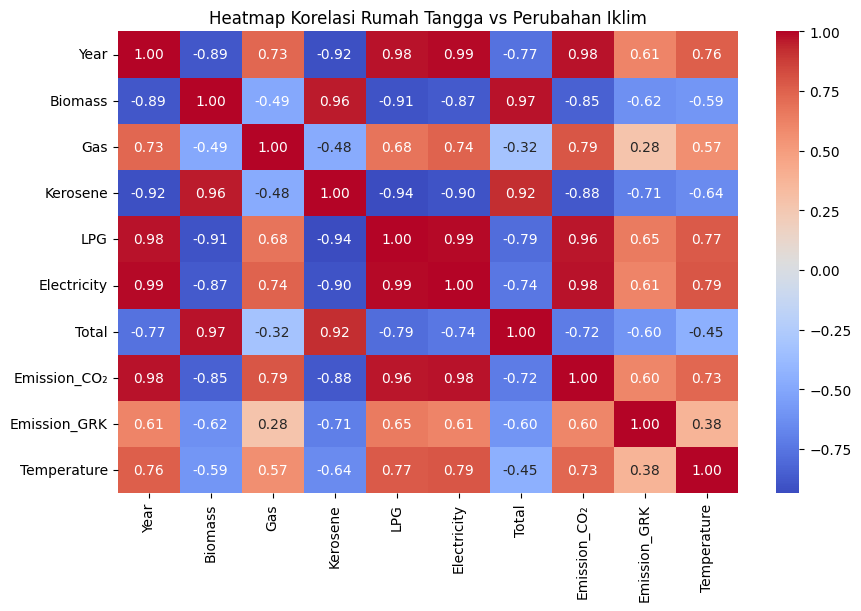

In [35]:
#3. Correlation beetween each dataset
display(Markdown("**3.3 Korelasi Data Energi Rumah Tangga dengan Perubahan Iklim**"))

# Menggabungkan data Rumah Tangga dengan Perubahan Iklim berdasarkan Year
df_rt_iklim = rumahtangga.merge(karbon, on="Year", suffixes=("", ""))
df_rt_iklim = df_rt_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_rt_iklim = df_rt_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_rt_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Rumah Tangga vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi rumah tangga dengan perubahan iklim. Penggunaan energi listrik, LPG, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

**3.4 Korelasi Data Energi Komersial dengan Perubahan Iklim**

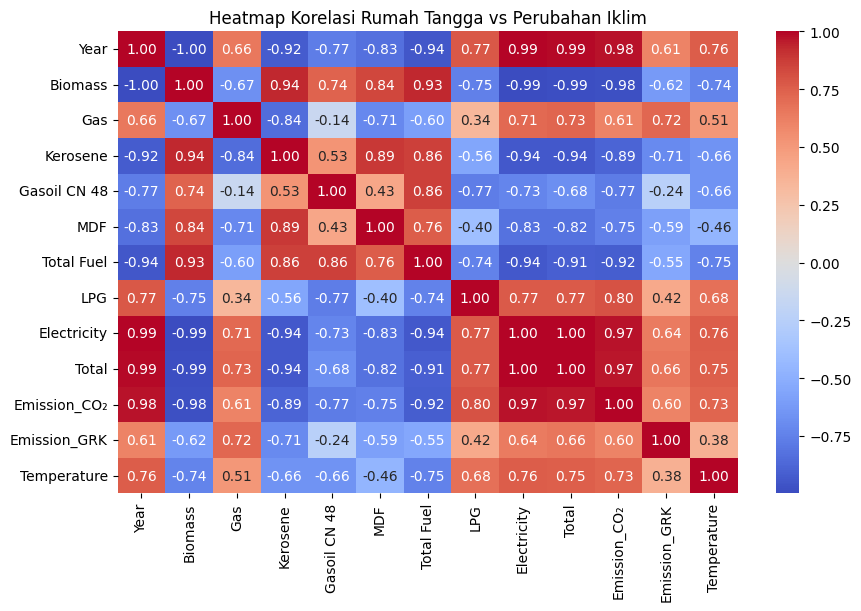

In [36]:
#3. Correlation beetween each dataset
display(Markdown("**3.4 Korelasi Data Energi Komersial dengan Perubahan Iklim**"))

# Menggabungkan data Komersial dengan Perubahan Iklim berdasarkan Year
df_kom_iklim = komersial.merge(karbon, on="Year", suffixes=("", ""))
df_kom_iklim = df_kom_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_kom_iklim = df_kom_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_kom_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Rumah Tangga vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi komersial dengan perubahan iklim. Penggunaan energi listrik, LPG, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

### **Step 4 : Modelling type 1**
**Predictive modelling with BVAR and Causality Test wtih Transfer Entropy**

In [37]:
display(Markdown("**1. Standarisasi Dataset**"))

**1. Standarisasi Dataset**

In [38]:
def standardize_datasets_to_vars(datasets, use_log=True):
    scalers = {}
    
    for name, df in datasets.items():
        df_copy = df.copy()

        # cek kalau ada kolom Year → pisahin
        if "Year" in df_copy.columns:
            years = df_copy["Year"]
            numeric_cols = df_copy.select_dtypes(include="number").columns.drop("Year")
        else:
            years = None
            numeric_cols = df_copy.select_dtypes(include="number").columns
        
        # ambil numeric data
        df_num = df_copy[numeric_cols].copy()
        
        # standarisasi
        scaler = StandardScaler()
        df_scaled = pd.DataFrame(
            scaler.fit_transform(df_num), 
            columns=numeric_cols, 
            index=df_copy.index
        )
        
        # gabungkan kembali dengan Year kalau ada
        if years is not None:
            df_scaled.insert(0, "Year", years)
        
        # simpan ke variabel tf_<nama>
        globals()[f"tf_{name}"] = df_scaled
        
        # simpan scaler untuk inverse transform
        scalers[name] = scaler
    
    return scalers

datasets = {
    "industri": industri,
    "rumahtangga": rumahtangga,
    "komersial": komersial,
    "karbon": karbon,
    "grk": grk,
    "temp": temp
}

scalers = standardize_datasets_to_vars(datasets, use_log=True)

In [39]:
print("> Hasil standarisasi dataset industri")
display(tf_industri.head(5))
print("> Hasil standarisasi dataset rumah tangga")
display(tf_rumahtangga.head(5))
print("> Hasil standarisasi dataset komersial")
display(tf_komersial.head(5))

> Hasil standarisasi dataset industri


,Year,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,Fuel Oil,Total Fuel,LPG,Electricity,Total
0,2000,1.302144,-0.909182,-0.007887,-2.148441,1.584433,0.629676,2.203209,1.390160,1.350883,0.611565,-1.179589,-0.521913
1,2001,1.133795,-0.897747,-0.133360,-0.939338,1.548731,0.775444,2.102060,1.561989,1.522812,0.135254,-1.120168,-0.426736
2,2002,1.005902,-0.877794,-0.043736,-1.048145,1.424680,0.700489,1.944966,1.392505,1.390910,0.705885,-1.073625,-0.438528
3,2003,0.911148,-0.526007,-0.151284,-0.291883,1.439808,0.644144,1.591873,0.635770,0.985745,-0.638163,-1.088404,-0.166592
4,2004,0.766975,-0.679734,-0.097510,-0.680790,1.459172,1.000312,1.408102,1.329652,1.305790,0.743612,-0.942335,-0.143416


> Hasil standarisasi dataset rumah tangga


,Year,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,1.293859,-0.660295,1.584439,-1.225847,-1.357953,1.281414
1,2001,1.336639,-0.639164,1.548616,-1.216581,-1.271454,1.347125
2,2002,1.384362,-0.607466,1.424709,-1.208677,-1.251075,1.370331
3,2003,1.429435,-0.596900,1.440015,-1.183759,-1.196238,1.453095
4,2004,1.464553,-0.508851,1.459078,-1.192130,-1.107910,1.522866


> Hasil standarisasi dataset komersial


,Year,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
0,2000,1.714015,-1.197836,1.582346,0.605502,2.206931,1.216664,-0.465649,-1.475886,-1.479338
1,2001,1.552468,-1.169418,1.546325,0.757264,2.137791,1.327101,-0.848119,-1.422556,-1.400431
2,2002,1.411114,-1.132256,1.421354,0.715414,1.930373,1.223393,-0.394940,-1.421249,-1.369880
3,2003,1.269760,-1.145372,1.436791,0.620678,1.584676,1.147789,-1.465214,-1.283478,-1.304629
4,2004,1.128406,-1.110396,1.455905,0.990885,1.377257,1.475539,-0.366014,-1.123574,-0.999622


In [40]:
print("> Hasil standarisasi dataset industri")
display(tf_karbon.head(5))
print("> Hasil standarisasi dataset rumah tangga")
display(tf_grk.head(5))
print("> Hasil standarisasi dataset komersial")
display(tf_temp.head(5))

> Hasil standarisasi dataset industri


,Year,Emission_CO₂
0,2000,-1.477429
1,2001,-1.208448
2,2002,-1.272808
3,2003,-1.040185
4,2004,-1.012576


> Hasil standarisasi dataset rumah tangga


,Year,Emission_GRK
0,2000,-1.028620
1,2001,-1.074537
2,2002,-0.342254
3,2003,-1.361023
4,2004,-1.036077


> Hasil standarisasi dataset komersial


,Year,Temperature
0,2000,-1.512702
1,2001,-0.814076
2,2002,-0.447002
3,2003,-0.367074
4,2004,-0.506208


In [41]:
display(Markdown("**2. Dekomposisi Dataset**"))

**2. Dekomposisi Dataset**

In [42]:
def detect_model(ts):
    if (ts <= 0).any():
        return "additive"

    rolling_mean = ts.rolling(window=3, min_periods=1).mean()
    rolling_std = ts.rolling(window=3, min_periods=1).std()
    cv = (rolling_std / rolling_mean).mean()

    return "multiplicative" if cv > 0.2 else "additive"


def decompose_dataset(df, freq=1, title="Dekomposisi Time Series", n_cols=2):
    numeric_cols = df.select_dtypes(include="number").columns.drop("Year", errors="ignore")
    n_attr = len(numeric_cols)
    n_rows = int(np.ceil(n_attr / n_cols))

    fig, axes = plt.subplots(n_rows * 4, n_cols, figsize=(6*n_cols, 3*n_rows*4), sharex=False)

    if n_rows * 4 == 1:
        axes = np.array([[axes]])
    elif axes.ndim == 1:
        axes = axes.reshape(n_rows*4, n_cols)

    for i, col in enumerate(numeric_cols):
        row_block = (i // n_cols) * 4
        col_block = i % n_cols

        ts = df.set_index("Year")[col].dropna() if "Year" in df.columns else df[col].dropna()
        model = detect_model(ts)
        result = seasonal_decompose(ts, model=model, period=freq)

        result.observed.plot(ax=axes[row_block, col_block], legend=False, title=f"{col} (Observed, {model})")
        result.trend.plot(ax=axes[row_block+1, col_block], legend=False, title="Trend")
        result.seasonal.plot(ax=axes[row_block+2, col_block], legend=False, title="Seasonal")
        result.resid.plot(ax=axes[row_block+3, col_block], legend=False, title="Residual")

    fig.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

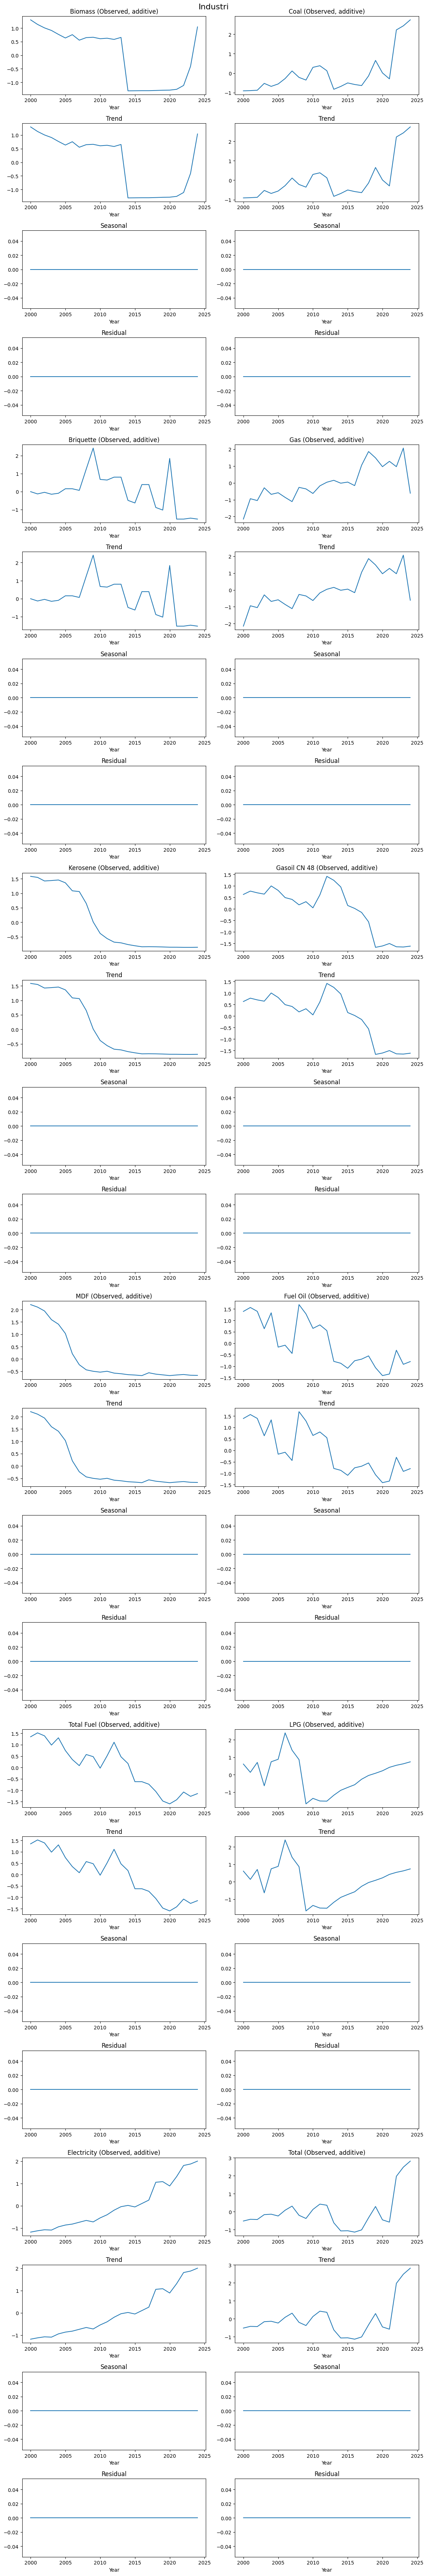

In [43]:
decompose_dataset(tf_industri, freq=1, title="Industri")

In [44]:
display(Markdown("**3. Uji Stasioneritas Dataset**"))

**3. Uji Stasioneritas Dataset**

In [45]:
df_ind_bvar = industri.add_prefix("Ind_")
df_rt_bvar = rumahtangga.add_prefix("RT_")
df_kom_bvar = komersial.add_prefix("Kom_")

df_energy_bvar = pd.concat([df_ind_bvar, df_rt_bvar, df_kom_bvar], axis=1)
# Cari nama kolom "Ind_Year" dan ganti dengan "Year"
df_energy_bvar = df_energy_bvar.rename(columns={"Ind_Year": "Year"})

# 4. Drop kolom tertentu (R-nya .drop())
cols_to_drop = ["RT_Year", "Kom_Year", "Ind_Sector", "RT_Sector", "Kom_Sector"]
df_energy_bvar = df_energy_bvar.drop(columns=cols_to_drop, errors="ignore")
data_energy_bvar = df_energy_bvar.dropna()


data_energy_bvar

,Year,Ind_Biomass,Ind_Coal,Ind_Geothermal,Ind_Briquette,Ind_Gas,Ind_Kerosene,Ind_Gasoil CN 48,Ind_MDF,Ind_BioGasoil,...,Kom_Biomass,Kom_Gas,Kom_Kerosene,Kom_Gasoil CN 48,Kom_MDF,Kom_BioGasoil,Kom_Total Fuel,Kom_LPG,Kom_Electricity,Kom_Total
0,2000,58981,36060,0,85,66826,4219,37171,8008,0,...,1452,134,3491,5352,43,0,8886,1257,8943,20670
1,2001,55186,37021,0,78,81861,4160,39458,7735,0,...,1444,147,3442,5682,42,0,9165,1138,9555,21450
2,2002,52303,38698,0,83,80508,3955,38282,7311,0,...,1437,164,3272,5591,39,0,8903,1279,9570,21752
3,2003,50167,68264,0,77,89912,3980,37398,6358,0,...,1430,158,3293,5385,34,0,8712,946,11151,22397
4,2004,46917,55344,0,80,85076,4012,42986,5862,0,...,1423,174,3319,6190,31,0,9540,1288,12986,25412
5,2005,43920,65744,0,94,86277,3851,39929,4843,0,...,1416,190,3186,5749,26,0,8961,1324,14344,26235
6,2006,46676,89043,0,94,82845,3394,35027,2627,0,...,1409,206,2809,5044,14,0,7866,1241,15473,26195
7,2007,42108,121904,0,89,79723,3352,33787,1422,0,...,1402,274,2774,4865,8,0,7646,1337,17237,27896
8,2008,44235,94035,0,155,90227,2676,30095,865,0,...,1395,357,2214,4333,5,0,6552,1044,18871,28219
9,2009,44521,82587,0,220,89101,1619,32238,706,0,...,1388,330,1394,4642,4,0,5985,1029,20482,29559


In [46]:
def adf_test_all(df, signif=0.05, exclude_cols=['Year', 'Sector', 'Entity', 'Country','Unit']):
    results = []
    for col in df.columns:
        if col not in exclude_cols:
            series = df[col].dropna()
            try:
                result = adfuller(series, autolag='AIC')
                p_value = result[1]
                status = "Stasioner" if p_value <= signif else "Tidak Stasioner"
                results.append((col, p_value, status))
            except:
                results.append((col, None, "Error"))
    return pd.DataFrame(results, columns=['Variable', 'p-value', 'Status'])

In [47]:
hasil_all = adf_test_all(data_energy_bvar)
hasil_all

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:958: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


,Variable,p-value,Status
0,Ind_Biomass,5.740463e-01,Tidak Stasioner
1,Ind_Coal,9.039533e-01,Tidak Stasioner
2,Ind_Geothermal,9.261437e-01,Tidak Stasioner
3,Ind_Briquette,9.763254e-01,Tidak Stasioner
4,Ind_Gas,7.186298e-02,Tidak Stasioner
5,Ind_Kerosene,3.108684e-12,Stasioner
6,Ind_Gasoil CN 48,9.248081e-01,Tidak Stasioner
7,Ind_MDF,8.935224e-03,Stasioner
8,Ind_BioGasoil,9.566911e-01,Tidak Stasioner
9,Ind_Fuel Oil,2.799084e-01,Tidak Stasioner


In [48]:
display(Markdown("**3.1 Uji Stasioneritas Dataset Energi Industri**"))
hasil_industri = adf_test_all(tf_industri)
hasil_industri

**3.1 Uji Stasioneritas Dataset Energi Industri**

,Variable,p-value,Status
0,Biomass,5.740463e-01,Tidak Stasioner
1,Coal,9.039533e-01,Tidak Stasioner
2,Briquette,9.763254e-01,Tidak Stasioner
3,Gas,7.186298e-02,Tidak Stasioner
4,Kerosene,3.108684e-12,Stasioner
5,Gasoil CN 48,9.248081e-01,Tidak Stasioner
6,MDF,8.935224e-03,Stasioner
7,Fuel Oil,2.799084e-01,Tidak Stasioner
8,Total Fuel,7.336552e-01,Tidak Stasioner
9,LPG,6.517448e-01,Tidak Stasioner


In [49]:
display(Markdown("**3.2 Uji Stasioneritas Dataset Energi Rumah Tangga**"))
hasil_rt = adf_test_all(rumahtangga)
hasil_rt

**3.2 Uji Stasioneritas Dataset Energi Rumah Tangga**

,Variable,p-value,Status
0,Biomass,9.198697e-04,Stasioner
1,Gas,9.986552e-01,Tidak Stasioner
2,Kerosene,3.588688e-11,Stasioner
3,LPG,7.123158e-01,Tidak Stasioner
4,Electricity,6.773078e-01,Tidak Stasioner
5,Total,2.036984e-30,Stasioner


In [50]:
display(Markdown("**3.3 Uji Stasioneritas Dataset Energi Komersial**"))
hasil_kom = adf_test_all(komersial)
hasil_kom

**3.3 Uji Stasioneritas Dataset Energi Komersial**

,Variable,p-value,Status
0,Biomass,8.447031e-01,Tidak Stasioner
1,Gas,2.642936e-01,Tidak Stasioner
2,Kerosene,2.798434e-07,Stasioner
3,Gasoil CN 48,9.592940e-01,Tidak Stasioner
4,MDF,1.847463e-02,Stasioner
5,BioGasoil,9.765215e-01,Tidak Stasioner
6,Total Fuel,8.478466e-01,Tidak Stasioner
7,LPG,9.599907e-01,Tidak Stasioner
8,Electricity,8.817620e-01,Tidak Stasioner
9,Total,9.546994e-01,Tidak Stasioner


In [51]:
display(Markdown("**3.4 Uji Stasioneritas Dataset Emisi CO₂**"))
hasil_karbon = adf_test_all(karbon)
hasil_karbon

**3.4 Uji Stasioneritas Dataset Emisi CO₂**

,Variable,p-value,Status
0,Emission_CO₂,0.986971,Tidak Stasioner


In [52]:
display(Markdown("**3.5 Uji Stasioneritas Dataset Emisi GRK**"))
hasil_grk = adf_test_all(grk)
hasil_grk

**3.5 Uji Stasioneritas Dataset Emisi GRK**

,Variable,p-value,Status
0,Emission_GRK,0.044673,Stasioner


In [53]:
display(Markdown("**3.6 Uji Stasioneritas Dataset Perubahan Suhu Permukaan**"))
hasil_temp = adf_test_all(temp)
hasil_temp

**3.6 Uji Stasioneritas Dataset Perubahan Suhu Permukaan**

,Variable,p-value,Status
0,Temperature,0.924788,Tidak Stasioner


In [54]:
display(Markdown("**4. Diferensiasi agar data menjadi Stasioner**"))

**4. Diferensiasi agar data menjadi Stasioner**

In [55]:
def try_transform(series, method):
    """Helper untuk transformasi"""
    if method == "log":
        shift = 0
        if (series <= 0).any():
            shift = abs(series.min()) + 1
        return np.log(series + shift), f"log (shift={shift})"

    elif method == "sqrt":
        shift = 0
        if (series < 0).any():
            shift = abs(series.min())
        return np.sqrt(series + shift), f"sqrt (shift={shift})"

    elif method == "boxcox":
        # hanya bisa untuk data positif
        if (series <= 0).any():
            return None, "boxcox (skip, ada nilai <=0)"
        transformed, lmbda = boxcox(series)
        return transformed, f"boxcox (λ={round(lmbda,3)})"

    elif method == "yeojohnson":
        transformed, lmbda = yeojohnson(series)
        return transformed, f"yeojohnson (λ={round(lmbda,3)})"

    else:
        return series, "original"
    
    

def make_stationary_advanced(series, signif=0.05, max_diff=2, name=''):
    """
    Coba berbagai transformasi (log, sqrt, boxcox, yeojohnson) + differencing 
    untuk bikin data stasioner.
    """
    series = pd.to_numeric(series, errors='coerce').dropna()
    methods = ["log", "sqrt", "boxcox", "yeojohnson"]

    # default hasil (sementara None, nanti isi original full test)
    best_result = {
        'Variable': name,
        'Transform': "original",
        'Final p-value': None,
        'Diff Applied': None,
        'Status': "Tidak Stasioner",
        'Transformed Series': series
    }

    # loop semua metode transformasi
    for method in ["original"] + methods:
        if method == "original":
            transformed = series.copy()
            note = "original"
        else:
            transformed, note = try_transform(series, method)
            if transformed is None:  # skip kalau gagal
                continue

        # differencing 0..max_diff
        for d in range(0, max_diff+1):
            temp = transformed.copy()
            for _ in range(d):
                temp = pd.Series(temp).diff().dropna()

            if len(temp) < 10:
                continue

            try:
                p_value = adfuller(temp, autolag='AIC')[1]
            except:
                p_value = 1.0

            if p_value <= signif:
                return {
                    'Variable': name,
                    'Transform': note,
                    'Final p-value': round(p_value, 4),
                    'Diff Applied': d,
                    'Status': "Stasioner",
                    'Transformed Series': temp
                }

            # kalau belum stasioner, simpan best model terakhir
            best_result = {
                'Variable': name,
                'Transform': note,
                'Final p-value': round(p_value, 4),
                'Diff Applied': d,
                'Status': "Tidak Stasioner",
                'Transformed Series': temp
            }

    return best_result

In [56]:
results = []
transformed = {}

for col in data_energy_bvar.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(data_energy_bvar[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

data_energy_bvar_stas = pd.DataFrame(transformed)
data_energy_bvar_stas.index = industri['Year'].iloc[-len(data_energy_bvar_stas):].values
data_energy_bvar = pd.DataFrame(results)
data_energy_bvar

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:958: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:958: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


,Variable,Transform,Final p-value,Diff Applied,Status
0,Ind_Biomass,original,0.0376,1,Stasioner
1,Ind_Coal,original,0.0000,2,Stasioner
2,Ind_Geothermal,original,0.0001,1,Stasioner
3,Ind_Briquette,original,0.0303,2,Stasioner
4,Ind_Gas,original,0.0000,1,Stasioner
5,Ind_Kerosene,original,0.0000,0,Stasioner
6,Ind_Gasoil CN 48,original,0.0038,1,Stasioner
7,Ind_MDF,original,0.0089,0,Stasioner
8,Ind_BioGasoil,original,0.0000,1,Stasioner
9,Ind_Fuel Oil,original,0.0000,1,Stasioner


In [57]:
data_energy_bvar_stas

,Ind_Biomass,Ind_Coal,Ind_Geothermal,Ind_Briquette,Ind_Gas,Ind_Kerosene,Ind_Gasoil CN 48,Ind_MDF,Ind_BioGasoil,Ind_Fuel Oil,...,Kom_Biomass,Kom_Gas,Kom_Kerosene,Kom_Gasoil CN 48,Kom_MDF,Kom_BioGasoil,Kom_Total Fuel,Kom_LPG,Kom_Electricity,Kom_Total
2000,NaN,NaN,NaN,NaN,NaN,4219,NaN,8008,NaN,NaN,...,NaN,NaN,3491,NaN,43,NaN,NaN,NaN,NaN,NaN
2001,-3795.0,NaN,0.0,NaN,15035.0,4160,2287.0,7735,0.0,1099.0,...,-8.0,13.0,3442,330.0,42,0.0,NaN,-119.0,NaN,780.0
2002,-2883.0,716.0,0.0,12.0,-1353.0,3955,-1176.0,7311,0.0,-1084.0,...,-7.0,17.0,3272,-91.0,39,0.0,-541.0,141.0,-597.0,302.0
2003,-2136.0,27889.0,0.0,-11.0,9404.0,3980,-884.0,6358,0.0,-4840.0,...,-7.0,-6.0,3293,-206.0,34,0.0,71.0,-333.0,1566.0,645.0
2004,-3250.0,-42486.0,0.0,9.0,-4836.0,4012,5588.0,5862,0.0,4438.0,...,-7.0,16.0,3319,805.0,31,0.0,1019.0,342.0,254.0,3015.0
2005,-2997.0,23320.0,0.0,11.0,1201.0,3851,-3057.0,4843,0.0,-9577.0,...,-7.0,16.0,3186,-441.0,26,0.0,-1407.0,36.0,-477.0,823.0
2006,2756.0,12899.0,0.0,-14.0,-3432.0,3394,-4902.0,2627,0.0,537.0,...,-7.0,16.0,2809,-705.0,14,0.0,-516.0,-83.0,-229.0,-40.0
2007,-4568.0,9562.0,0.0,-5.0,-3122.0,3352,-1240.0,1422,0.0,-2298.0,...,-7.0,68.0,2774,-179.0,8,0.0,875.0,96.0,635.0,1701.0
2008,2127.0,-60730.0,0.0,71.0,10504.0,2676,-3692.0,865,0.0,13626.0,...,-7.0,83.0,2214,-532.0,5,0.0,-874.0,-293.0,-130.0,323.0
2009,286.0,16421.0,0.0,-1.0,-1126.0,1619,2143.0,706,0.0,-2594.0,...,-7.0,-27.0,1394,309.0,4,0.0,527.0,-15.0,-23.0,1340.0


In [58]:
data_energy_bvar_stas.to_csv("data_energy_bvar_stas.csv", index=True)

In [59]:
results = []
transformed = {}

for col in tf_industri.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_industri[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_ind_stationary = pd.DataFrame(transformed)
df_ind_stationary.index = industri['Year'].iloc[-len(df_ind_stationary):].values
hasil_difind = pd.DataFrame(results)
print(hasil_difind)

        Variable                       Transform  Final p-value  Diff Applied  \
0        Biomass                        original         0.0376             1   
1           Coal                        original         0.0000             2   
2      Briquette                        original         0.0303             2   
3            Gas                        original         0.0000             1   
4       Kerosene                        original         0.0000             0   
5   Gasoil CN 48                        original         0.0038             1   
6            MDF                        original         0.0089             0   
7       Fuel Oil                        original         0.0000             1   
8     Total Fuel                        original         0.0001             1   
9            LPG  log (shift=2.6756743048605536)         0.0277             1   
10   Electricity   log (shift=2.179589059469378)         0.0000             2   
11         Total            

In [60]:
results = []
transformed = {}

for col in tf_rumahtangga.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_rumahtangga[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_rt_stationary = pd.DataFrame(transformed)
df_rt_stationary.index = tf_rumahtangga['Year'].iloc[-len(df_rt_stationary):].values
hasil_difrt = pd.DataFrame(results)
print(hasil_difrt)

      Variable                        Transform  Final p-value  Diff Applied  \
0      Biomass                         original         0.0009             0   
1          Gas  sqrt (shift=0.6602953861602427)         0.0006             1   
2     Kerosene                         original         0.0000             0   
3          LPG   log (shift=2.2258470757847935)         0.0000             0   
4  Electricity              yeojohnson (λ=0.76)         0.0466             1   
5        Total                         original         0.0000             0   

      Status  
0  Stasioner  
1  Stasioner  
2  Stasioner  
3  Stasioner  
4  Stasioner  
5  Stasioner  


In [61]:
results = []
transformed = {}

for col in tf_komersial.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_komersial[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_kom_stationary = pd.DataFrame(transformed)
df_kom_stationary.index = tf_komersial['Year'].iloc[-len(df_kom_stationary):].values
hasil_difkom = pd.DataFrame(results)
print(hasil_difkom)

       Variable Transform  Final p-value  Diff Applied     Status
0       Biomass  original         0.0000             1  Stasioner
1           Gas  original         0.0412             1  Stasioner
2      Kerosene  original         0.0000             0  Stasioner
3  Gasoil CN 48  original         0.0043             1  Stasioner
4           MDF  original         0.0185             0  Stasioner
5    Total Fuel  original         0.0004             2  Stasioner
6           LPG  original         0.0006             1  Stasioner
7   Electricity  original         0.0029             2  Stasioner
8         Total  original         0.0001             1  Stasioner


In [62]:
results = []
transformed = {}

for col in tf_karbon.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_karbon[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_karbon_stationary = pd.DataFrame(transformed)
df_karbon_stationary.index = tf_karbon['Year'].iloc[-len(df_karbon_stationary):].values
hasil_difkarbon = pd.DataFrame(results)
print(hasil_difkarbon)

       Variable Transform  Final p-value  Diff Applied     Status
0  Emission_CO₂  original            0.0             2  Stasioner


In [63]:
results = []
transformed = {}

for col in tf_grk.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_grk[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_grk_stationary = pd.DataFrame(transformed)
df_grk_stationary.index = tf_grk['Year'].iloc[-len(df_grk_stationary):].values
hasil_difgrk = pd.DataFrame(results)
print(hasil_difgrk)

       Variable Transform  Final p-value  Diff Applied     Status
0  Emission_GRK  original         0.0447             0  Stasioner


In [64]:
results = []
transformed = {}

for col in tf_temp.columns:
    if col not in ['Year','Sector','Entity','Country','Unit']:
        res = make_stationary_advanced(tf_temp[col], name=col)
        results.append({k: v for k, v in res.items() if k != 'Transformed Series'})
        transformed[col] = res['Transformed Series']

df_temp_stationary = pd.DataFrame(transformed)
df_temp_stationary.index = tf_temp['Year'].iloc[-len(df_temp_stationary):].values
hasil_diftemp = pd.DataFrame(results)
print(hasil_diftemp)

      Variable Transform  Final p-value  Diff Applied     Status
0  Temperature  original            0.0             1  Stasioner


In [65]:
display(Markdown("**2. Modelling with BVAR**"))

**2. Modelling with BVAR**

In [66]:
df_ind_bvar = df_ind_stationary.add_prefix("Ind_")
df_rt_bvar = df_rt_stationary.add_prefix("RT_")
df_kom_bvar = df_kom_stationary.add_prefix("Kom_")

df_energy_bvar = pd.concat([df_ind_bvar, df_rt_bvar, df_kom_bvar], axis=1)
data_energy_bvar = df_energy_bvar.dropna()

data_energy_bvar

,Ind_Biomass,Ind_Coal,Ind_Briquette,Ind_Gas,Ind_Kerosene,Ind_Gasoil CN 48,Ind_MDF,Ind_Fuel Oil,Ind_Total Fuel,Ind_LPG,...,RT_Total,Kom_Biomass,Kom_Gas,Kom_Kerosene,Kom_Gasoil CN 48,Kom_MDF,Kom_Total Fuel,Kom_LPG,Kom_Electricity,Kom_Total
2002,-0.127892,0.008519,0.215096,-0.108807,1.424680,-0.074956,1.944966,-0.169484,-0.131902,0.184822,...,1.370331,-0.141354,0.037162,1.421354,-0.041849,1.930373,-0.214146,0.453179,-0.052023,0.030551
2003,-0.094755,0.331833,-0.197172,0.756262,1.439808,-0.056344,1.591873,-0.756735,-0.405164,-0.506608,...,1.453095,-0.141354,-0.013116,1.436791,-0.094736,1.584676,0.028104,-1.070273,0.136463,0.065250
2004,-0.144173,-0.505514,0.161322,-0.388907,1.459172,0.356168,1.408102,0.693882,0.320044,0.517703,...,1.522866,-0.141354,0.034976,1.455905,0.370207,1.377257,0.403354,1.099200,0.022134,0.305007
2005,-0.132949,0.277470,0.197172,0.096583,1.361747,-0.194847,1.030556,-1.497366,-0.559529,0.040544,...,1.518145,-0.141354,0.034976,1.358133,-0.202809,1.031560,-0.556937,0.115705,-0.041566,0.083257
2006,0.122258,0.153477,-0.250946,-0.275999,1.085205,-0.312444,0.209514,0.083960,-0.396101,0.355199,...,1.503610,-0.141354,0.034976,1.080990,-0.324218,0.201887,-0.204250,-0.266765,-0.019955,-0.004047
2007,-0.202640,0.113772,-0.089623,-0.251069,1.059790,-0.079035,-0.236946,-0.359293,-0.269378,-0.218039,...,1.594688,-0.141354,0.148647,1.055260,-0.082319,-0.212949,0.346354,0.308547,0.055335,0.172079
2008,0.094355,-0.722587,1.272654,0.844723,0.650726,-0.235321,-0.443318,2.130428,0.489778,-0.142471,...,-0.696144,-0.141354,0.181437,0.643589,-0.244658,-0.420368,-0.345958,-0.941712,-0.011328,0.032676
2009,0.012687,0.195383,-0.017925,-0.090552,0.011110,0.136591,-0.502229,-0.405572,-0.093846,-1.264664,...,-0.819802,-0.141354,-0.059022,0.040785,0.142104,-0.489507,0.208604,-0.048211,-0.002004,0.135559
2010,-0.053410,0.789456,-2.903801,-0.271174,-0.385246,-0.266999,-0.537056,-0.631655,-0.505428,0.274573,...,-0.808997,-0.141354,1.383732,-0.398086,0.091057,-0.558647,0.087875,0.041782,-0.034856,0.117349
2011,0.018055,-0.569800,1.702846,0.451393,-0.561943,0.563253,-0.500747,0.151972,0.541345,-0.121802,...,-0.797022,-0.282707,-0.078696,-0.501739,0.216605,-0.558647,0.267583,0.253909,0.134546,0.315123


In [67]:
data_energy_bvar.to_csv("data_energy_bvar.csv", index=True)

### **Step 5 : Modelling type 2**
**Predictive modelling with Seq2Seq and Causality Test with Transfer Entropy**

In [68]:
# Heningkan warning retracing
tf.get_logger().setLevel("ERROR")

-> Siapkan Dataset Energi (Industri, Rumah Tangga, dan Komersial)

In [69]:
datasets = {
    "industri": tf_industri,
    "rumahtangga": tf_rumahtangga,
    "komersial": tf_komersial
}

-> Set parameter dan Set Seed

In [70]:
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

-> Set Hyper Parameter for LSTM function

In [71]:
param_grid = { 
    "latent_dim": [256], 
    "activation": ["tanh"], 
    "optimizer": ["adam"], 
    "learning_rate": [0.0001], 
    "batch_size": [8], 
    "timesteps": [3], 
}

horizon = 5
epochs = 50
val_ratio = 0.2
test_ratio = 0.15

-> Membuat Fungsi bantu untuk Seq2Seq 

In [72]:
def make_sequences(data: np.ndarray, timesteps: int, horizon: int = 5):
    X, y = [], []
    T = data.shape[0]
    if T <= timesteps + horizon:
        raise ValueError("Data terlalu pendek untuk kombinasi timesteps dan horizon ini.")
    for i in range(T - timesteps - horizon + 1):
        X.append(data[i:i + timesteps])
        y.append(data[i + timesteps:i + timesteps + horizon])
    return np.array(X), np.array(y)

-> Membangun model Seq2Seq berbasis LSTM

In [73]:
def build_seq2seq_lstm(timesteps, n_features, latent_dim=128, horizon=1,
                       activation="tanh", optimizer_name="adam", lr=1e-3):
    encoder_inputs = Input(shape=(timesteps, n_features))
    encoder = LSTM(latent_dim, activation=activation, return_state=True)
    _, state_h, state_c = encoder(encoder_inputs)
    encoder_states = [state_h, state_c]

    repeated = RepeatVector(horizon)(state_h)
    decoder = LSTM(latent_dim, activation=activation, return_sequences=True)
    dec_out = decoder(repeated, initial_state=encoder_states)

    outputs = TimeDistributed(Dense(n_features))(dec_out)

    if optimizer_name.lower() == "adam":
        opt = Adam(learning_rate=lr)
    else :
        opt = Nadam(learning_rate=lr)

    model = Model(encoder_inputs, outputs)
    model.compile(optimizer=opt, loss="mse")
    return model

-> Inverse Transform

In [74]:
def inverse_transform(y_seq, numeric_cols, scaler):
    """Mengembalikan data hasil prediksi ke skala asli."""
    N, h, f = y_seq.shape
    y_flat = y_seq.reshape((N*h, f))
    inv = scaler.inverse_transform(y_flat)
    return inv.reshape((N, h, f))

-> Evaluasi dan visualisasi

In [75]:
def evaluate_model(y_true, y_pred, var_name):
    """
    y_true, y_pred: shape (N, horizon, n_features) 
    for univariate n_features==1
    returns DataFrame indexed by var_name with columns MAE, RMSE
    """
    y_t = y_true.reshape(-1)
    y_p = y_pred.reshape(-1)
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    df = pd.DataFrame({"MAE": [mae], "RMSE": [rmse]}, index=[var_name])
    return df

-> Looping untuk data energi

In [76]:
all_best_results = {}
summary_rows = []

for name, df in datasets.items():
    print(f"\n🚀 Optimizing dataset: {name.upper()}")

    # buang kolom non-numerik
    if "Year" in df.columns:
        df_features = df.drop(columns=["Year"])
    else:
        df_features = df.copy()

    numeric_cols = list(df_features.columns)
    sector_best_results = []
    sector_summary = []

    for col in numeric_cols:
        print(f"\n⚙️ Forecasting attribute: {col}")
        data_arr = df_features[[col]].values
        n_features = 1

        best_score = np.inf
        best_params = None
        best_result = None
        t0 = time.time()

        for params in itertools.product(*param_grid.values()):
            p = dict(zip(param_grid.keys(), params))
            try:
                # === DATA SPLIT ===
                X_all, y_all = make_sequences(data_arr, timesteps=p["timesteps"], horizon=horizon)
                N = X_all.shape[0]
                test_size = int(N * test_ratio)
                val_size = int(N * val_ratio)
                train_size = N - val_size - test_size

                X_train, y_train = X_all[:train_size], y_all[:train_size]
                X_val, y_val = X_all[train_size:train_size+val_size], y_all[train_size:train_size+val_size]
                X_test, y_test = X_all[train_size+val_size:], y_all[train_size+val_size:]

                # === BANGUN MODEL ===
                model = build_seq2seq_lstm(
                    timesteps=p["timesteps"],
                    n_features=n_features,
                    latent_dim=p["latent_dim"],
                    horizon=horizon,
                    activation=p["activation"],
                    optimizer_name=p["optimizer"],
                    lr=p["learning_rate"]
                )

                es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)

                model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=p["batch_size"],
                    callbacks=[es],
                    verbose=0
                )

                # === PREDIKSI ===
                y_pred = model.predict(X_test, verbose=0)
                if tf.is_tensor(y_pred):  # pastikan bukan Tensor
                    y_pred = y_pred.numpy()

                # === EVALUASI ===
                result = evaluate_model(y_test, y_pred, col)
                rmse_val = float(result["RMSE"].values[0])

                if rmse_val < best_score:
                    best_score = rmse_val
                    best_params = p
                    best_result = result

                # === EARLY STOP kalau model sudah sangat bagus ===
                if best_score < 0.05:
                    print(f"✅ {col} sudah sangat bagus (RMSE={best_score:.4f}), hentikan pencarian parameter.")
                    break

            except Exception as e:
                print(f"⚠️ Error on {col} with params {p}: {e}")
                continue

        t1 = time.time()
        print(f"✅ Best RMSE for {col}: {best_score:.4f} | Waktu: {(t1 - t0)/60:.2f} menit")
        print("Best Params:", best_params)

        # === SIMPAN HASIL TERBAIK ===
        sector_best_results.append(best_result)
        sector_summary.append({
            "Attribute": col,
            "Best RMSE": best_score,
            **best_params
        })

    # === REKAP PER DATASET ===
    sector_result_df = pd.concat(sector_best_results)
    all_best_results[name] = sector_result_df

    summary_df = pd.DataFrame(sector_summary)
    summary_rows.append({"Dataset": name, "Summary": summary_df})

    print(f"\n=== 🧾 Evaluation Results for {name.upper()} ===")
    display(sector_result_df)


🚀 Optimizing dataset: INDUSTRI

⚙️ Forecasting attribute: Biomass
✅ Best RMSE for Biomass: 0.7673 | Waktu: 0.29 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Coal
✅ Best RMSE for Coal: 1.7299 | Waktu: 0.22 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Briquette
✅ Best RMSE for Briquette: 1.5427 | Waktu: 0.21 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Gas
✅ Best RMSE for Gas: 0.8425 | Waktu: 0.27 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Kerosene
✅ Best RMSE for Kerosene: 0.1409 | Waktu: 0.27 menit
Best 

,MAE,RMSE
Biomass,0.665730,0.767345
Coal,1.335341,1.729873
Briquette,1.527043,1.542689
Gas,0.651465,0.842524
Kerosene,0.114096,0.140922
Gasoil CN 48,1.587582,1.588744
MDF,0.084344,0.099918
Fuel Oil,0.942094,1.019512
Total Fuel,1.143094,1.160938
LPG,0.454501,0.496386



🚀 Optimizing dataset: RUMAHTANGGA

⚙️ Forecasting attribute: Biomass
✅ Best RMSE for Biomass: 0.3483 | Waktu: 0.27 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Gas
✅ Best RMSE for Gas: 1.7668 | Waktu: 0.22 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Kerosene
✅ Best RMSE for Kerosene: 0.1694 | Waktu: 0.25 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: LPG
✅ Best RMSE for LPG: 0.5986 | Waktu: 0.27 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Electricity
✅ Best RMSE for Electricity: 0.8524 | Waktu: 0.27 menit


,MAE,RMSE
Biomass,0.345554,0.348318
Gas,1.504208,1.766790
Kerosene,0.149372,0.169383
LPG,0.590737,0.598583
Electricity,0.825147,0.852357
Total,0.080623,0.112901



🚀 Optimizing dataset: KOMERSIAL

⚙️ Forecasting attribute: Biomass
✅ Best RMSE for Biomass: 0.6225 | Waktu: 0.26 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Gas
✅ Best RMSE for Gas: 0.7735 | Waktu: 0.22 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Kerosene
✅ Best RMSE for Kerosene: 0.1448 | Waktu: 0.27 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: Gasoil CN 48
✅ Best RMSE for Gasoil CN 48: 1.6556 | Waktu: 0.21 menit
Best Params: {'latent_dim': 256, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 8, 'timesteps': 3}

⚙️ Forecasting attribute: MDF
✅ Best RMSE for MDF: 0.0831 | Waktu: 0.25 menit


,MAE,RMSE
Biomass,0.606373,0.622467
Gas,0.676846,0.773519
Kerosene,0.117009,0.144828
Gasoil CN 48,1.640247,1.655600
MDF,0.064014,0.083089
Total Fuel,0.943432,0.948809
LPG,1.221407,1.324801
Electricity,0.499887,0.573251
Total,0.523093,0.659523


-> Hasil Seq2Seq by LSTM

In [77]:
summary_rows = []
for name, result_list in all_best_results.items():
    for r in result_list:
        row = {
            "Dataset": name,
            "Variable": r["variable"],
            "Best RMSE": r["best_score"],
            **{f"param_{k}": v for k, v in r["best_params"].items()},
            "MAE": r["best_metrics"]["MAE"],
            "RMSE": r["best_metrics"]["RMSE"],
            "Epochs_max": epochs
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n=== Summary of Best Models (All Datasets) ===")
display(summary_df)

TypeError: string indices must be integers, not 'str'

12. Transfer Entropy

In [ ]:
# tf_industri = tf_industri[tf_industri['Year'] != 2024]
# tf_rumahtangga = tf_rumahtangga[tf_rumahtangga['Year'] != 2024]
# tf_komersial = tf_komersial[tf_komersial['Year'] != 2024]


In [ ]:
# def discretize(series, bins=5):
#     """Ubah data float jadi kategori integer"""
#     return pd.cut(series, bins=bins, labels=False).astype(int)

# def compute_te(x, y, k=1):
#     """Hitung Transfer Entropy dari x -> y"""
#     return pyinform.transferentropy.transfer_entropy(x, y, k)

# # --- Hasil TE ---
# results = []

# # Loop energi per kolom
# for e_name, df_e in {
#     "Industri": tf_industri,
#     "Rumahtangga": tf_rumahtangga,
#     "Komersial": tf_komersial
# }.items():
#     for col in df_e.drop(columns=["Year"]).columns:
#         e_data = discretize(df_e[col])

#         # Loop iklim per dataset
#         for i_name, df_i in {
#             "Karbon": tf_karbon,
#             "GRK": tf_grk,
#             "Temp": tf_temp
#         }.items():
#             i_data = discretize(df_i.drop(columns=["Year"]).squeeze())

#             # Samakan panjang
#             min_len = min(len(e_data), len(i_data))
#             e_data = e_data[:min_len]
#             i_data = i_data[:min_len]

#             try:
#                 te_value = compute_te(e_data, i_data, k=1)
#                 results.append({"From": f"{e_name}_{col}", "To": i_name, "TE": te_value})
#             except Exception as ex:
#                 results.append({"From": f"{e_name}_{col}", "To": i_name, "TE": np.nan})
#                 print(f"Error TE {e_name}_{col} -> {i_name}: {ex}")

# # --- Tampilkan hasil ---
# df_te = pd.DataFrame(results)
# print("\n=== Transfer Entropy Energi -> Iklim ===")
# df_te